# Data Quality Report

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import regex as re
from difflib import SequenceMatcher

import nltk
from nltk.corpus import stopwords

In [2]:
transcript = pd.read_csv('../Data/CSV/final_transcript.csv', delimiter=',')

In [3]:
transcript['Start Time'] = pd.to_datetime(transcript['Start Time'], format='ISO8601')
transcript['End Time'] = pd.to_datetime(transcript['End Time'], format='ISO8601')

In [4]:
transcript.tail(10)

,Start Time,End Time,Sentence,Translation,Emotion_fine,Emotion_core,Intensity
1217,1900-01-01 00:40:50.274986,1900-01-01 00:40:51.614986,the search for a new chef.,the search for a new chef.,anticipation,neutral,neutral
1218,1900-01-01 00:40:51.614986,1900-01-01 00:40:53.514986,"Hi, how are you?","Hi, how are you?",curiosity,neutral,neutral
1219,1900-01-01 00:40:53.574986,1900-01-01 00:40:55.614986,"And thanks to her transformation,","And thanks to her transformation,",gratitude,happiness,mild
1220,1900-01-01 00:40:55.614986,1900-01-01 00:40:57.774986,not only is her business back on track.,not only is her business back on track.,relief,happiness,mild
1221,1900-01-01 00:40:57.774986,1900-01-01 00:41:02.114986,It's the first Charlie's staff meeting.,It's the first Charlie's staff meeting.,anticipation,neutral,mild
1222,1900-01-01 00:41:02.114986,1900-01-01 00:41:04.655986,But so is her relationship with her family.,But so is her relationship with her family.,concern,sadness,mild
1223,1900-01-01 00:41:04.655986,1900-01-01 00:41:07.454986,"I owe Chef Ramsay, like, everything.","I owe Chef Ramsay, like, everything.",gratitude,happiness,moderate
1224,1900-01-01 00:41:07.454986,1900-01-01 00:41:10.135986,He has molded me into the business owner I nee...,He has molded me into the business owner I nee...,gratitude,happiness,moderate
1225,1900-01-01 00:41:10.135986,1900-01-01 00:41:11.635986,"When he comes back, he's going to be like,","When he comes back, he's going to be like,",anticipation,surprise,mild
1226,1900-01-01 00:41:11.635986,1900-01-01 00:41:14.035986,"you've got it, Tatiana, yes.","you've got it, Tatiana, yes.",encouragement,happiness,mild


## Dataset Profile

### 1. Basic size metrics

*Size of the dataset*

In [5]:
transcript.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1227 entries, 0 to 1226
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Start Time    1227 non-null   datetime64[ns]
 1   End Time      1227 non-null   datetime64[ns]
 2   Sentence      1227 non-null   object        
 3   Translation   1227 non-null   object        
 4   Emotion_fine  1227 non-null   object        
 5   Emotion_core  1227 non-null   object        
 6   Intensity     1227 non-null   object        
dtypes: datetime64[ns](2), object(5)
memory usage: 67.2+ KB


*Total vocoabulary size*

In [6]:
sentences = np.array(transcript['Sentence'])

- Minimal preprocessing

In [7]:
def sentence_processor_minimal(sentence):
    """
    - Basic tokenization (split on whitespace + handle punctuation)
    - Convert to lowercase
    """
    tokens = sentence.split()
    processed_tokens = []
    
    for token in tokens:
        # Remove punctuation from edges but keep the core word
        cleaned_token = re.sub(r'^[^\w]+|[^\w]+$', '', token)
        if cleaned_token:  # Only keep non-empty tokens
            processed_tokens.append(cleaned_token.lower())
    
    return processed_tokens

In [8]:
def sentence_list_processor_min(sentences_list):
    return [sentence_processor_minimal(sentence) for sentence in sentences_list]

In [9]:
sentences_min_cleaned = sentence_list_processor_min(sentences)

In [10]:
vocabulary = list(sorted(set([word for sentence in sentences_min_cleaned for word in sentence])))
print(vocabulary[-10:])

['yet', 'yo', 'you', "you'd", "you're", "you've", 'young', 'your', 'yours', 'zucchini']


In [11]:
print(f'Vocabulary size (minimal preprocessing): {len(vocabulary)}')

Vocabulary size (minimal preprocessing): 1130


- Proper preprocessing

In [12]:
nltk.download('stopwords')
stopwords_english = stopwords.words('english') 
print(stopwords_english)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Erik\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
def sentence_processor(sentence):
    """
    - Remove immediate repetitions (ASR aware)
    - Common filler words (ASR aware)
    - Basic tokenization (split on whitespace + handle punctuation)
    - Removes stopwords
    - Convert to lowercase
    """
    sentence = re.sub(r'\b(\w+)\s+\1\b', r'\1', sentence)
    sentence = re.sub(r'\b(um|uh|er|ah)\b', '', sentence, flags=re.IGNORECASE)
    
    tokens = sentence.split()
    processed_tokens = []

    for token in tokens:
        # Remove punctuation from edges but keep the core word
        cleaned_token = re.sub(r'^[^\w]+|[^\w]+$', '', token)
        if cleaned_token and cleaned_token not in stopwords_english:
            processed_tokens.append(cleaned_token.lower())
    
    return processed_tokens

In [14]:
def sentence_list_processor(sentences_list):
    return [sentence_processor(sentence) for sentence in sentences_list]

In [15]:
sentences_cleaned = sentence_list_processor(sentences)

In [16]:
vocabulary = list(sorted(set([word for sentence in sentences_cleaned for word in sentence])))
print(vocabulary[-10:])

['yeah', 'years', 'yes', 'yet', 'yo', 'you', "you're", "you've", 'young', 'zucchini']


In [17]:
print(f'Vocabulary size: {len(vocabulary)}')

Vocabulary size: 1070


*Total number of tokens*

In [18]:
sentences_cleaned = sentence_list_processor(np.array(transcript['Sentence']))

In [19]:
total_tokens = sum(len(sentence) for sentence in sentences_cleaned)
print(f'Total number of tokens: {total_tokens}')

Total number of tokens: 3814


### 2. Missing Values Check

- Empty strings ("")
- Whitespace-only entries
- Placeholder values like "N/A", "unknown", etc.

In [20]:
transcript_copy = transcript.copy()

In [21]:
error_values = ['', ' ', 'n/a', 'unknown', '[inaudible]', '[unknown speaker]', 
               '[silence]', '[music]', '[noise]', 'unintelligible', '[?]']

for col in transcript_copy.columns:
    if transcript_copy[col].dtype == 'object':
        mask = transcript_copy[col].astype(str).str.lower().isin([val.lower() for val in error_values])
        transcript_copy.loc[mask, col] = np.nan

missing_values = transcript_copy.isnull()

print(missing_values.any())

Start Time      False
End Time        False
Sentence        False
Translation     False
Emotion_fine    False
Emotion_core    False
Intensity       False
dtype: bool


### 3. Duplicates Analysis

- Exact sentence duplicates (same text)
- Near-duplicates (very similar sentences)
- Time overlaps

In [22]:
sentences = transcript['Sentence']
start_times = transcript['Start Time']
end_times = transcript['End Time']

*Exact sentence duplicates*

In [23]:
sentence_duplicates = sentences[sentences.duplicated(keep=False)]
print(sentence_duplicates)

23                                 That's not good.
32                                    I don't know.
34                                         Tatiana.
51                                       All right.
84                                     Oh, my gosh.
                           ...                     
1089                   I don't know what to do now.
1110    Why are you guys not talking to each other?
1134                                     Oh my god.
1141                                        I know.
1166                                          Good.
Name: Sentence, Length: 194, dtype: object


In [24]:
duplicate_counts = sentence_duplicates.sort_values(ascending=False)
print(duplicate_counts.head(20))

1035           Yes.
1042           Yes.
233            Yes.
1054           Yes.
288     Yes, it is.
320     Yes, it is.
333     Yes, it is.
431           Yeah.
263           Yeah.
445           Yeah.
771           Yeah.
432           Yeah.
703           Yeah.
299           Yeah.
112           Yeah.
948           Yeah.
88            Yeah.
475            Wow.
328            Wow.
456            Wow.
Name: Sentence, dtype: object


*Near-duplicates*

In [25]:
def similarity_ratio(a, b):
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

In [26]:
print('\nChecking for near-duplicates...')
near_duplicates = []
sentences_list = sentences.tolist()

for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        sim = similarity_ratio(sentences[i], sentences[j])
        if sim > 0.85:
            near_duplicates.append((i, j, sim, sentences[i], sentences[j]))

print(f'Near-duplicate pairis found: {len(near_duplicates)}')
if near_duplicates:
    for i, j, sim, sent1, sent2 in near_duplicates[:20]:
        if int(sim) != 1:
            print(f'\nSimiliarity: {sim:.3f}')
            print(f'Sentence {i}: {sent1}')
            print(f'Sentence {j}: {sent2}')


Checking for near-duplicates...
Near-duplicate pairis found: 682

Similiarity: 0.875
Sentence 34: Tatiana.
Sentence 1059: Tatiana?

Similiarity: 0.857
Sentence 83: How are you?
Sentence 1218: Hi, how are you?

Similiarity: 0.870
Sentence 84: Oh, my gosh.
Sentence 359: Oh, my god.

Similiarity: 0.870
Sentence 84: Oh, my gosh.
Sentence 373: Oh, my god.

Similiarity: 0.870
Sentence 84: Oh, my gosh.
Sentence 635: Oh, my god.

Similiarity: 0.857
Sentence 84: Oh, my gosh.
Sentence 773: Oh, gosh.


*Date Overlaps*

In [27]:
# Check for time overlaps
overlaps = []
for i in range(len(transcript)-1):
    current_end = transcript.iloc[i]['End Time']
    next_start = transcript.iloc[i+1]['Start Time']
    
    if current_end > next_start:
        overlap_duration = current_end - next_start
        overlaps.append({
            'index1': i,
            'index2': i+1,
            'overlap_seconds': overlap_duration.total_seconds(),
            'sentence1': transcript.iloc[i]['Sentence'],
            'sentence2': transcript.iloc[i+1]['Sentence']
        })

print(f"\nTime overlaps found: {len(overlaps)}")

overlap_df = pd.DataFrame(overlaps)
print("\nWorst overlaps:")
overlap_df.nlargest(3, 'overlap_seconds')[['overlap_seconds', 'sentence1', 'sentence2']]


Time overlaps found: 3

Worst overlaps:


,overlap_seconds,sentence1,sentence2
1,1.334987,Wow.,what's going on now?
2,0.895009,I need everyone on their game.,"Good night, guys."
0,0.876009,"Yeah, a lot of people don't like them.","They're either really raw, or they're just, li..."


### 4. Sentence Length Analysis

- Character count distribution
- Word count distribution
- Compare lengths between original and translated text

**Sentence Lengths Analysis** shows how the lengths of sentences are spread across the dataset. This is useful for:
  - Identifying ASR transcription artifacts (for example, very shorts sentences might be transcription fragments and very long sentences might be transcriptions where the ASR failed to detect sentencve boundaries)
  - Understanding the series patterns
  - Looking at both the original transcript and the translations, there should be a correlation between the original and the translation
  - Model training implications (very short sentences might not show emotional context and very long sentences might be harder for emotion detection)

In [28]:
sentences = transcript['Sentence']
translations = transcript['Translation']

*Character count distribution*

In [29]:
original_char_counts = sentences.str.len()
translated_char_counts = translations.str.len()

In [30]:
print(f'The longest sentence: {max(original_char_counts)}')

The longest sentence: 64


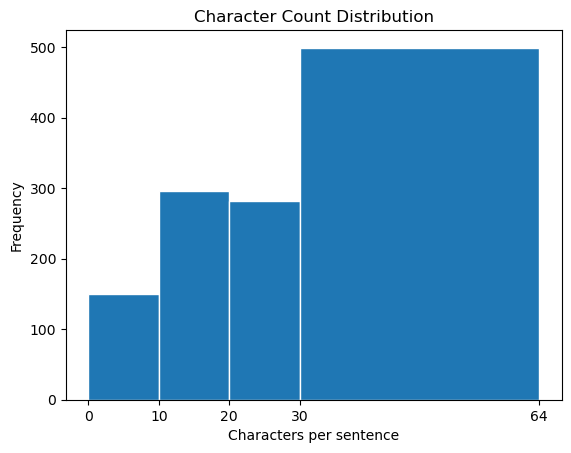

In [31]:
bins = [0, 10, 20, 30, 64]

plt.hist(original_char_counts, bins=bins, edgecolor='white')
plt.xlabel('Characters per sentence')
plt.ylabel('Frequency')
plt.title('Character Count Distribution')
plt.xticks(bins) 
plt.show()

In [32]:
print(f"Original sentences - Mean: {original_char_counts.mean():.1f}, Median: {original_char_counts.median():.1f}")
print(f"Translated sentences - Mean: {translated_char_counts.mean():.1f}, Median: {translated_char_counts.median():.1f}")

Original sentences - Mean: 26.7, Median: 25.0
Translated sentences - Mean: 26.7, Median: 25.0


In [33]:
very_short = transcript[original_char_counts < 10]
very_long = transcript[original_char_counts > 50]

print(f"\nVery short sentences (< 10 chars): {len(very_short)}")
if len(very_short) > 0:
    print("Examples:", very_short['Sentence'].head(3).tolist())

print(f"\nLonger sentences (> 50 chars): {len(very_long)}")
if len(very_long) > 0:
    print("Examples:", very_long['Sentence'].head(1).tolist())


Very short sentences (< 10 chars): 150
Examples: ['Tatiana.', 'Rude.', 'Stop it.']

Longer sentences (> 50 chars): 92
Examples: ['La Verne, California, just 30 miles from Los Angeles,']


*Word count distribution*

In [34]:
original_word_counts = sentences.str.split().str.len()
translated_word_counts = translations.str.split().str.len()

In [35]:
print(f'The longest sentence: {max(original_word_counts)}')

The longest sentence: 13


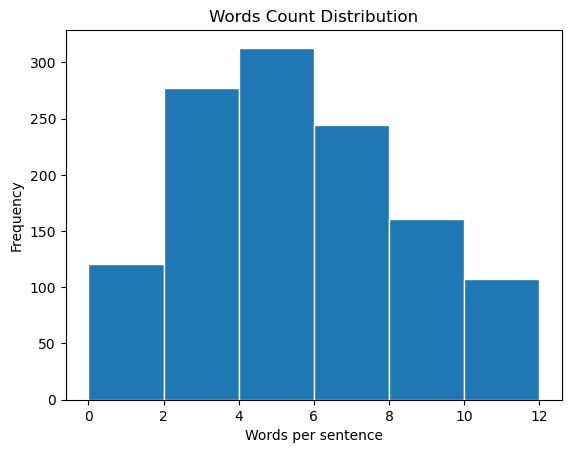

In [36]:
bins = range(0,13,2)

plt.hist(original_word_counts, bins=bins, edgecolor='white')
plt.xlabel('Words per sentence')
plt.ylabel('Frequency')
plt.title('Words Count Distribution')
plt.xticks(bins) 
plt.show()

*Original - Translation*

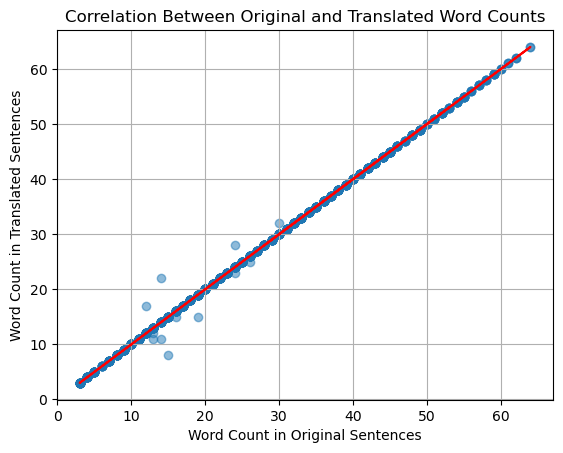

In [37]:
plt.scatter(original_char_counts, translated_char_counts, alpha=0.5)
plt.xlabel('Word Count in Original Sentences')
plt.ylabel('Word Count in Translated Sentences')
plt.title('Correlation Between Original and Translated Word Counts')

# Best Fit
m, b = np.polyfit(original_char_counts, translated_char_counts, 1)
plt.plot(original_char_counts, m * original_char_counts + b, color = 'red')

plt.grid()
plt.show()

In [38]:
correlation = np.corrcoef(original_char_counts, translated_char_counts)[0,1]
print(f"Correlation between original and translated lengths: {correlation:.3f}")

Correlation between original and translated lengths: 1.000


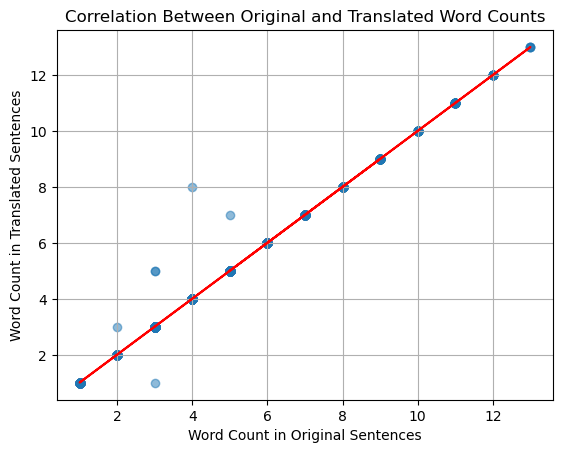

In [39]:
plt.scatter(original_word_counts, translated_word_counts, alpha=0.5)
plt.xlabel('Word Count in Original Sentences')
plt.ylabel('Word Count in Translated Sentences')
plt.title('Correlation Between Original and Translated Word Counts')

# Best Fit
m, b = np.polyfit(original_word_counts, translated_word_counts, 1)
plt.plot(original_word_counts, m * original_word_counts + b, color = 'red')

plt.grid()
plt.show()

In [40]:
short_sentences = transcript[original_word_counts <= 3]['Sentence']
print("Short sentences (might be kitchen commands):")
print(short_sentences.tolist())

Short sentences (might be kitchen commands):
["called Charlie's.", 'Of course.', "That's not good.", "I don't know.", 'Tatiana.', "it's ridiculous.", "No, they're crazy.", 'All right.', "She's very disrespectful.", 'Rude.', 'Stop it.', 'I told you.', "Don't you dare.", 'Hi.', 'How are you?', 'Oh, my gosh.', 'And this is?', 'Tatiana.', 'Tatiana.', 'Yeah.', 'Is Charlie in?', "No, he's not.", 'Who is he?', 'Charlie owned it.', 'Charlie owned it.', 'No, no.', 'Oh, okay.', 'Okay, great.', 'Mm-hmm.', 'Oh, is it?', 'Yeah.', 'Caprice, hello.', "I'm Val.", 'And this is?', "I'm Pat.", 'Shall we?', "Let's go outside.", 'Excellent.', 'Her dream.', 'OK.', 'Really?', 'My condo, yeah.', 'Wow.', 'Probably like $1,000.', 'OK.', "That's not good.", 'Tatiana.', 'Right.', 'Wow.', "I don't know.", "You don't know?", 'Wow.', 'Nothing changed.', 'OK.', 'Right.', 'Wow.', 'Wow.', 'OK.', 'Thank you.', 'Thank you.', 'Rice.', 'Here we go.', 'Oh, my word.', 'OK.', "Let's go.", 'OK.', 'OK.', 'The lasagna.', 'Are yo

### 5. Domain-Specific Vocabulary and Patterns

- Domain specific vocabulary
- Pattern analysis
- Emotional language patterns

In [41]:
sentences = transcript['Sentence']

In [42]:
freqs = {}
for sentence in sentences_cleaned:
    for token in sentence:
        freqs[token] = freqs.get(token, 0) + 1

freqs = dict(sorted(freqs.items(), key=lambda x: x[1], reverse=True))

*Domain specific vocabulary*

In [43]:
cooking_terms =  ['chef', 'kitchen', 'cook', 'season', 'salt', 'pepper', 'fire', 'pan', 
                'oil', 'heat', 'temperature', 'minutes', 'seconds', 'taste', 'flavor',
                'behind', 'hot', 'sharp', 'knife', 'plate', 'service', 'order'] # generated by Claude

In [44]:
cooking_freq = {term: freqs.get(term, 0) for term in cooking_terms}
cooking_df = pd.DataFrame.from_dict(cooking_freq, orient='index', columns=['count'])
cooking_df = cooking_df.sort_values('count', ascending=False)

print('Kitchen vocabulary frequency:')
print(cooking_df[cooking_df['count'] > 0])

Kitchen vocabulary frequency:
         count
chef        57
kitchen     15
cook        10
taste        7
pan          4
order        4
hot          4
minutes      3
fire         3
season       2
seconds      2
flavor       2
plate        1
salt         1
oil          1
service      1
knife        1


*Pattern analysis*

In [45]:
command_sentences = transcript[sentences.str.split().str.len() <= 3]['Sentence']
explanation_sentences = transcript[sentences.str.split().str.len() >= 8]['Sentence']

In [46]:
print(f'Possible command sentences (≤3 words): {len(command_sentences)} ({len(command_sentences)/len(transcript)*100:.1f}%)')
print('Examples:', command_sentences.head(10).tolist())

Possible command sentences (≤3 words): 398 (32.4%)
Examples: ["called Charlie's.", 'Of course.', "That's not good.", "I don't know.", 'Tatiana.', "it's ridiculous.", "No, they're crazy.", 'All right.', "She's very disrespectful.", 'Rude.']


In [47]:
print(f'Explanation sentences (≥8 words): {len(explanation_sentences)} ({len(explanation_sentences)/len(transcript)*100:.1f}%)')
print('Examples:', explanation_sentences.head(3).tolist())

Explanation sentences (≥8 words): 272 (22.2%)
Examples: ['La Verne, California, just 30 miles from Los Angeles,', 'this suburb is home to a neighborhood Italian bistro', 'And in 2010, it was bought by the Leyva family.']


*Emotional language patterns*

In [48]:
intensity_words = ['amazing', 'terrible', 'disgusting', 'perfect', 'disaster', 
                   'beautiful', 'horrible', 'excellent', 'awful', 'fantastic',
                   'shit', 'damn', 'hell', 'brilliant', 'phenomenal'] # generated by Claude

In [49]:
print("\nEmotional words by labeled emotions:")
for emotion in transcript['Emotion_core'].unique():
    emotion_sentences = transcript[transcript['Emotion_core'] == emotion]['Sentence']
    emotion_has_intensity = emotion_sentences.str.contains('|'.join(intensity_words), case=False)
    print(f"{emotion}: {emotion_has_intensity.sum()}/{len(emotion_sentences)} sentences contain intensity words")


Emotional words by labeled emotions:
neutral: 2/472 sentences contain intensity words
happiness: 10/247 sentences contain intensity words
sadness: 4/164 sentences contain intensity words
fear: 1/69 sentences contain intensity words
anger: 5/106 sentences contain intensity words
surprise: 1/107 sentences contain intensity words
disgust: 7/62 sentences contain intensity words


In [ ]:
swear_words = ['fuck', 'fucking', 'shit', 'damn', 'hell']
swear_count = sum(freqs.get(word, 0) for word in swear_words)
print(f"\nStrong language: {swear_count} instances found")


Strong language: 22 instances found


### 6. Token Distribution

- Word frequency distributions
- Special characters and symbols

In [51]:
sentences = transcript['Sentence']
sentences_cleaned = sentence_list_processor(np.array(transcript['Sentence']))

In [52]:
freqs = {}
for sentence in sentences_cleaned:
    for token in sentence:
        freqs[token] = freqs.get(token, 0) + 1

freqs = dict(sorted(freqs.items(), key=lambda x: x[1], reverse=True))
freqs_df = pd.DataFrame.from_dict(freqs, orient='index', columns=['count'])

*Word frequency*

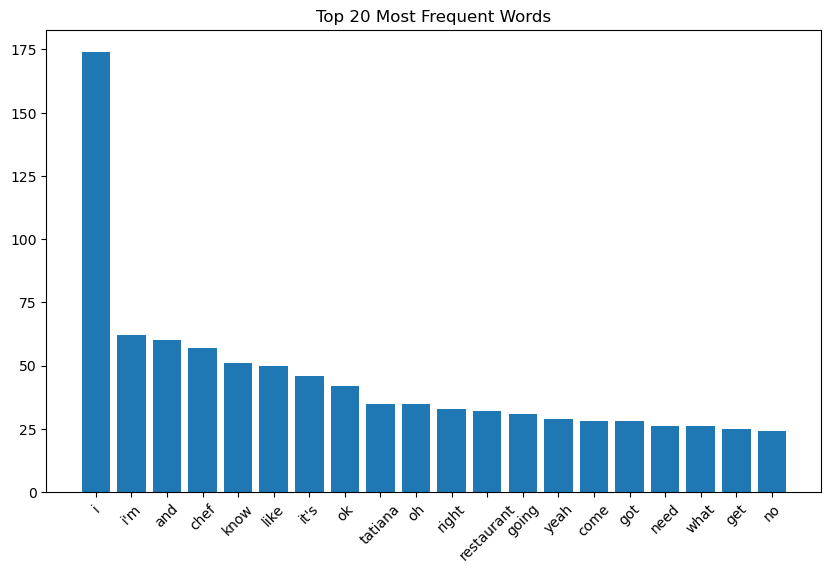

In [53]:
plt.figure(figsize=(10, 6))
top_20_words = freqs_df.head(20)
plt.bar(range(len(top_20_words)), top_20_words['count'])
plt.xticks(range(len(top_20_words)), top_20_words.index, rotation=45)
plt.title('Top 20 Most Frequent Words')
plt.show()

In [54]:
rare_words = freqs_df[freqs_df['count'] == 1]

print('Rarest words:')
print(rare_words.head(10))

Rarest words:
              count
30                1
los               1
angeles           1
suburb            1
home              1
neighborhood      1
2010              1
leyva             1
booth             1
ago               1


In [55]:
print(f'Words appearing only once: {len(rare_words)}')

Words appearing only once: 564


*Special characters and symbols*

In [56]:
special_chars = {}
for sentence in sentences:
    for char in sentence:
        if not char.isalnum() and not char.isspace():
            special_chars[char] = special_chars.get(char, 0) + 1

In [57]:
print('Special characters:')
special_df = pd.DataFrame.from_dict(special_chars, orient='index', columns=['count'])
print(special_df.sort_values('count', ascending=False))

Special characters:
   count
.    929
'    484
,    418
?    176
-      5
$      2
!      2


In [58]:
bracket_patterns = transcript['Sentence'].str.contains(r'\[.*\]').sum()
print(f'Sentences with ASR artifacts: {bracket_patterns}')

Sentences with ASR artifacts: 0


## Show Distributions & Emotion Analysis

### 1. Timely Analysis

- Episode progression
- Intensity progression
- Peak Emotion Moments

In [59]:
transcript_time = transcript.copy()

In [60]:
transcript_time.tail()

,Start Time,End Time,Sentence,Translation,Emotion_fine,Emotion_core,Intensity
1222,1900-01-01 00:41:02.114986,1900-01-01 00:41:04.655986,But so is her relationship with her family.,But so is her relationship with her family.,concern,sadness,mild
1223,1900-01-01 00:41:04.655986,1900-01-01 00:41:07.454986,"I owe Chef Ramsay, like, everything.","I owe Chef Ramsay, like, everything.",gratitude,happiness,moderate
1224,1900-01-01 00:41:07.454986,1900-01-01 00:41:10.135986,He has molded me into the business owner I nee...,He has molded me into the business owner I nee...,gratitude,happiness,moderate
1225,1900-01-01 00:41:10.135986,1900-01-01 00:41:11.635986,"When he comes back, he's going to be like,","When he comes back, he's going to be like,",anticipation,surprise,mild
1226,1900-01-01 00:41:11.635986,1900-01-01 00:41:14.035986,"you've got it, Tatiana, yes.","you've got it, Tatiana, yes.",encouragement,happiness,mild


In [61]:
start_time = transcript_time['Start Time'].min()
end_time = transcript_time['End Time'].max()
total_duration = end_time-start_time

print(f'Total duration: {total_duration}')

Total duration: 0 days 00:41:14.035986


In [62]:
first_third = start_time + total_duration / 3
second_third = start_time + 2 * total_duration / 3

In [63]:
time_bins = [start_time, first_third, second_third, end_time]
time_labels = ['Beginning', 'Middle', 'End']

transcript_time['Section'] = pd.cut(transcript_time['Start Time'],
                                    bins=time_bins,
                                    labels=time_labels,
                                    include_lowest=True)

In [64]:
section_counts = transcript_time['Section'].value_counts()
print('Sentences per time section:')
for section in time_labels:
    count = section_counts[section]
    pct = count / len(transcript_time) * 100
    print(f'{section}: {count} sentences ({pct:.1f}%)')

Sentences per time section:
Beginning: 430 sentences (35.0%)
Middle: 394 sentences (32.1%)
End: 403 sentences (32.8%)


*Episode progression*

In [65]:
emotion_by_section = pd.crosstab(transcript_time['Section'], 
                                transcript_time['Emotion_core'], 
                                normalize='index') * 100

print("Emotion distribution by episode section (%):")
print(emotion_by_section.round(1))

Emotion distribution by episode section (%):
Emotion_core  anger  disgust  fear  happiness  neutral  sadness  surprise
Section                                                                  
Beginning       8.4      9.3   7.9       12.1     39.1     12.8      10.5
Middle         13.2      5.1   6.9       10.2     40.1     15.5       9.1
End             4.5      0.5   2.0       38.5     36.2     11.9       6.5


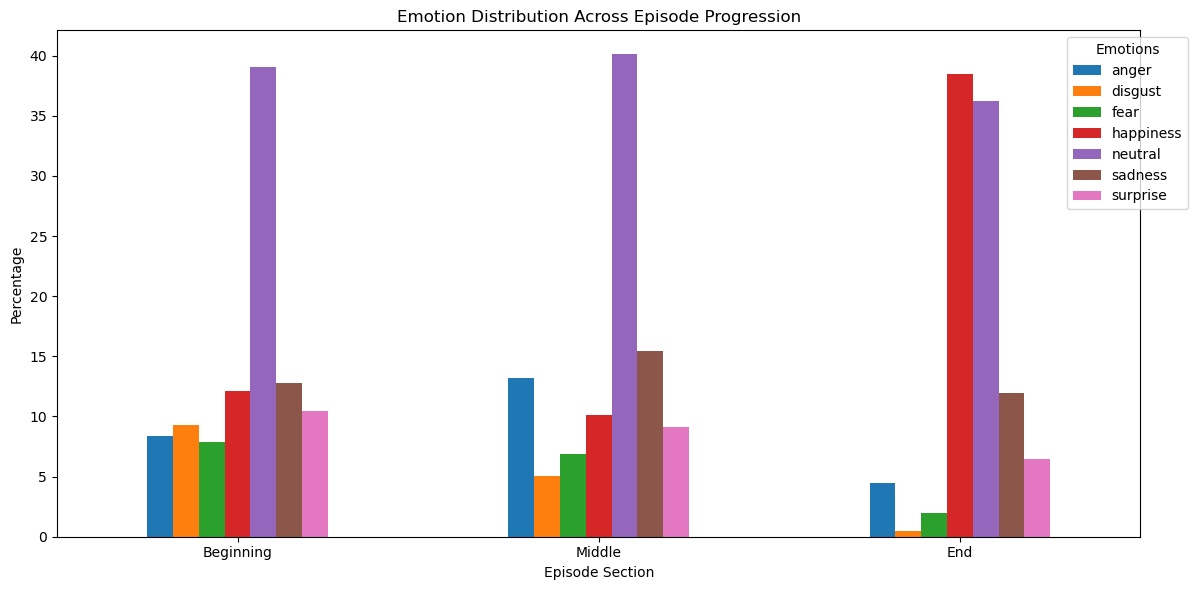

In [66]:
emotion_by_section.plot(kind='bar', figsize=(12, 6))
plt.title('Emotion Distribution Across Episode Progression')
plt.xlabel('Episode Section')
plt.ylabel('Percentage')
plt.legend(title='Emotions', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

*Intensity Progression*

In [67]:
intensity_by_section = pd.crosstab(transcript_time['Section'],
                                   transcript_time['Intensity'],
                                   normalize='index') * 100

print("Intensity distribution by episode section (%):")
print(intensity_by_section.round(1))

Intensity distribution by episode section (%):
Intensity  intense  mild  moderate  neutral
Section                                    
Beginning      3.0  45.3      23.5     28.1
Middle         4.6  44.4      24.6     26.4
End            4.5  45.9      25.8     23.8


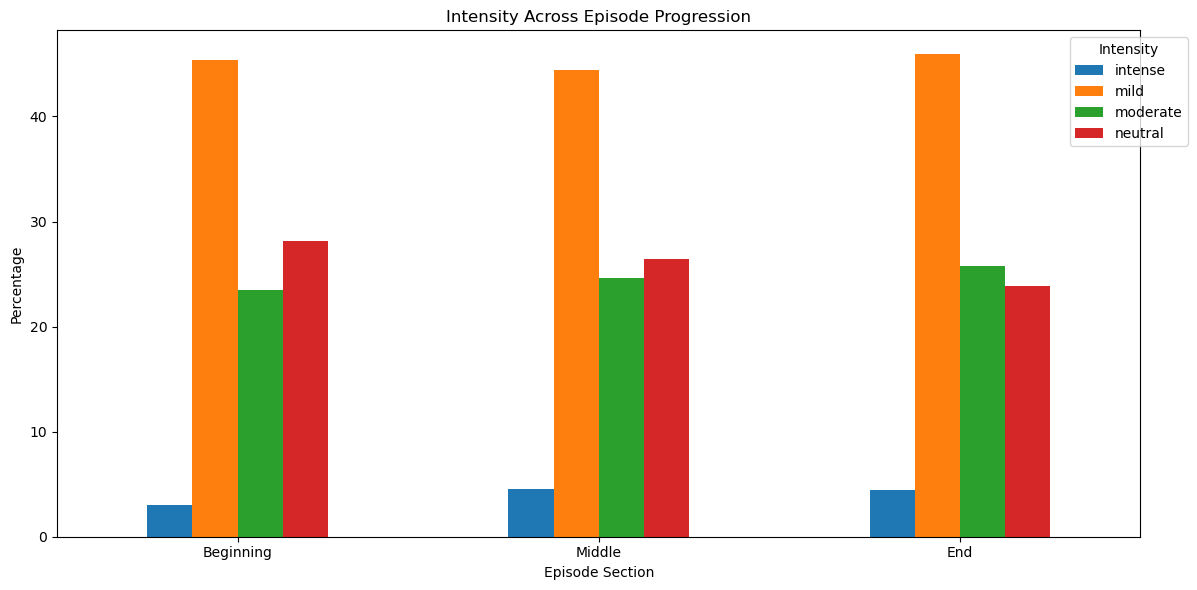

In [68]:
intensity_by_section.plot(kind='bar', figsize=(12, 6))
plt.title('Intensity Across Episode Progression')
plt.xlabel('Episode Section')
plt.ylabel('Percentage')
plt.legend(title='Intensity', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

*Peak Emotion Moments*

In [69]:
print('Emotion peaks by section:')
for emotion in transcript_time['Emotion_core'].unique():
    peak_section = emotion_by_section[emotion].idxmax()
    peak_value = emotion_by_section[emotion].max()
    print(f'{emotion} peaks in {peak_section} ({peak_value:.1f}%)')

Emotion peaks by section:
neutral peaks in Middle (40.1%)
happiness peaks in End (38.5%)
sadness peaks in Middle (15.5%)
fear peaks in Beginning (7.9%)
anger peaks in Middle (13.2%)
surprise peaks in Beginning (10.5%)
disgust peaks in Beginning (9.3%)


### 2. Emotion Distribution & Coverage

- Core emotion frequency
- Emotion_fine mapping
- Underrepresentation

*Core emotion frequency*

In [70]:
emotion_counts = transcript_time['Emotion_core'].value_counts()
emotion_pct = transcript_time['Emotion_core'].value_counts(normalize=True) * 100

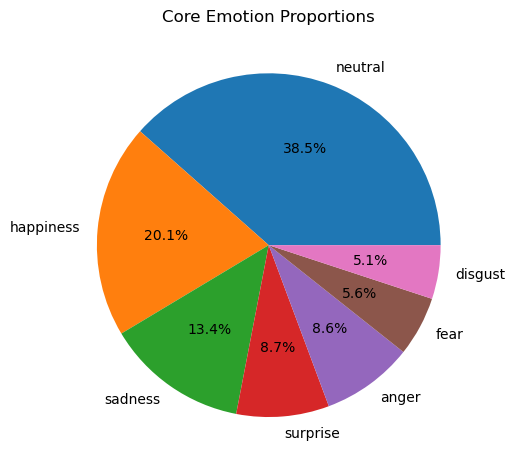

In [71]:
plt.pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%')
plt.title('Core Emotion Proportions')

plt.tight_layout()
plt.show()

*Fine-Grained Emotion*

In [72]:
fine_emotion_counts = transcript['Emotion_fine'].value_counts()
print(f'Total unique fine emotions: {len(fine_emotion_counts)}')
print(f'Top 10 most frequent fine emotions:')
print(fine_emotion_counts.head(10))

Total unique fine emotions: 203
Top 10 most frequent fine emotions:
Emotion_fine
curiosity         116
anticipation       69
neutrality         49
disappointment     44
frustration        43
confusion          39
uncertainty        36
acceptance         35
resignation        31
concern            23
Name: count, dtype: int64


In [73]:
fine_to_core_mapping = transcript.groupby('Emotion_fine')['Emotion_core'].first()
print('Fine-to-core emotion mapping examples:')
for fine, core in fine_to_core_mapping.head(10).items():
    count = fine_emotion_counts[fine]
    print(f'{fine} -> {core} ({count} instances)')

Fine-to-core emotion mapping examples:
acceptance -> neutral (35 instances)
accommodation -> neutral (1 instances)
accomplishment -> happiness (1 instances)
accusation -> anger (5 instances)
acknowledgment -> neutral (6 instances)
acquisition -> neutral (1 instances)
admiration -> happiness (18 instances)
adoration -> happiness (1 instances)
affection -> happiness (7 instances)
affirmation -> neutral (2 instances)


*<20% representation*

In [74]:
threshold = 20.0
underrep_core = emotion_pct[emotion_pct < threshold]
print('Underrepresented core emotions:')
for emotion, pct in underrep_core.items():
    print(f'{emotion}: {pct:.1f}%')

Underrepresented core emotions:
sadness: 13.4%
surprise: 8.7%
anger: 8.6%
fear: 5.6%
disgust: 5.1%


## Domain Characteristics Analysis

### 1. Spoken TV Language Patterns

- Informal language
- Hesitations and fillers
- Incompletes
- Domain-specific language (performed already in Dataset Profile step 5)

In [75]:
sentences = transcript['Sentence']

In [91]:
informal_patterns = {
    'contractions': r"\w+'[a-z]+",  # don't, can't, it's
    'fillers': r'\b(um|uh|like|you know|well|so|wow)\b',
    'incomplete': r'\w+\.\.\.',  # words ending with ...
}

In [100]:
print("Informal patterns found:")
for pattern_name, pattern in informal_patterns.items():
    sentence_has_patterns = sentences.str.contains(pattern, case=False)
    count = sentence_has_patterns.sum()
    pct = count / len(sentences) * 100
    print(f'{pattern_name.title()}: {count}/{len(sentences)} sentences ({pct:.1f}%)')

    examples = sentences[sentence_has_patterns].head(3).tolist()
    if examples:
        print('\tExamples:')
        for ex in examples:
            print(f'\t\t{ex}')
    print()

Informal patterns found:
Contractions: 434/1227 sentences (35.4%)
	Examples:
		called Charlie's.
		but I didn't have the money or the collateral,
		My mom and I don't know about the restaurant business,

Fillers: 131/1227 sentences (10.7%)
	Examples:
		Would you like a booth?
		so I had to go to my mom and my sister.
		and so we put a lot of trust in my sister's experience

Incomplete: 0/1227 sentences (0.0%)



C:\Users\Erik\AppData\Local\Temp\ipykernel_34620\3942158130.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  sentence_has_patterns = sentences.str.contains(pattern, case=False)


### 2. Transcription & Translation Artifacts

Transcription:
 - missing punctuation
 - cut-off sentences
 - repeated words
 - time/number formatting
 - translation length mismatches

In [101]:
sentences = transcript['Sentence']
translations = transcript['Translation']

*Missing punctuation*

In [121]:
no_punctuation = sentences.str.match(r'^[^,.!?]*$') # excluding early cut-offs
print(f'Missing punctuation: {no_punctuation.sum()}/{len(sentences)} sentences)')
if no_punctuation.sum() > 0:
    print('Examples:', sentences[no_punctuation].head(3).tolist())

Missing punctuation: 55/1227 sentences)
Examples: ['this suburb is home to a neighborhood Italian bistro', 'Pat and Val both full-time school teachers', 'finance the restaurant and put their houses up as collateral']


*Early cut-offs*

In [ ]:
cut_offs = sentences.str.match(r'.*,$')
print(f'Early cut-offs: {cut_offs.sum()}/{len(sentences)} sentences)')
if cut_offs.sum() > 0:
    print('Examples:', sentences[cut_offs].head(3).tolist())
    

Early cut-offs: 46/1227 sentences)
Examples: ['La Verne, California, just 30 miles from Los Angeles,', 'And then I had the opportunity to take it over,', "but I didn't have the money or the collateral,"]


*Repeated words*

In [130]:
repeated_word_pattern = r'\b(\w+)\s+\1\b' # same word twice in a row
repeated_sentences = sentences.str.contains(repeated_word_pattern, case=False)

print(f'Sentences with repeated words: {repeated_sentences.sum()}')
if repeated_sentences.sum() > 0:
    examples = sentences[repeated_sentences].head(3)
    print('Examples:')
    for ex in examples:
        print(f'\t{ex}')

Sentences with repeated words: 1
Examples:
	Ha ha ha.


C:\Users\Erik\AppData\Local\Temp\ipykernel_34620\1834438840.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  repeated_sentences = sentences.str.contains(repeated_word_pattern, case=False)


*Time/number formatting*

In [137]:
number_patterns = {
    'written_numbers': sentences.str.contains(r'\b(one|two|three|four|five|six|seven|eight|nine|ten)\b', case=False).sum(),
    'digit_numbers': sentences.str.contains(r'\b\d+\b').sum(),
    'time_formats': sentences.str.contains(r'\b\d+\s*(minutes?|mins?|seconds?|secs?)\b', case=False).sum(),
}

print('Number/Time formatting:')
for pattern, count in number_patterns.items():
    print(f"{pattern.replace('_', ' ').title()}: {count} occurrences")

Number/Time formatting:
Written Numbers: 43 occurrences
Digit Numbers: 16 occurrences
Time Formats: 1 occurrences


C:\Users\Erik\AppData\Local\Temp\ipykernel_34620\201748946.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'written_numbers': sentences.str.contains(r'\b(one|two|three|four|five|six|seven|eight|nine|ten)\b', case=False).sum(),
C:\Users\Erik\AppData\Local\Temp\ipykernel_34620\201748946.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'time_formats': sentences.str.contains(r'\b\d+\s*(minutes?|mins?|seconds?|secs?)\b', case=False).sum(),


*Translation length mismatches*

In [133]:
original_lengths = sentences.str.len()
translation_lengths = translations.str.len()
length_ratios = translation_lengths / original_lengths

print(f'Average length ratio (translation/original): {length_ratios.mean():.2f}')
print(f'Standard deviation: {length_ratios.std():.2f}')

Average length ratio (translation/original): 1.00
Standard deviation: 0.03


In [135]:
extreme_short = length_ratios < 0.5
extreme_long = length_ratios > 2.0

print('Extreme mismatches:')
print(f'Translation much shorter (<50% of original): {extreme_short.sum()} sentences')
print(f'Translation much longer (>200% of original): {extreme_long.sum()} sentences')

Extreme mismatches:
Translation much shorter (<50% of original): 0 sentences
Translation much longer (>200% of original): 0 sentences
